# 07. Agente de insights (RAG-lite) con Groq

**Proyecto**: Pronóstico de demanda multi-series (Curso II — Especialización ML Engineering)

Este notebook cubre la **Fase 5**: un agente genAI que genera un *insight* de negocio
para una serie del subconjunto (tienda × artículo) combinando tres pasos:

1. **Contexto**: estadísticas del histórico y del pronóstico ene-mar 2018 de la serie.
2. **Retrieval**: búsqueda de las series del dataset con perfil histórico más parecido
   (similitud de coseno sobre TF-IDF de las fichas de serie).
3. **Generación**: un LLM de **Groq** (`llama-3.3-70b-versatile`, API compatible con
   OpenAI) redacta el insight usando el contexto y las series similares como evidencia.

> La clave se lee de `.env` (`GROQ_API_KEY`, tier gratuito de https://console.groq.com).
> Sin clave, el notebook usa un **generador heurístico** (baseline determinista) para que
> el flujo completo funcione; al configurar la clave y re-ejecutar se usa el LLM.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Localiza la raíz del proyecto estés donde estés (desde notebooks/ o desde la raíz)
def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "raw" / "train.csv").exists():
            return p
    raise FileNotFoundError("No se encontró la raíz del proyecto (data/raw/train.csv)")

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

from dotenv import dotenv_values
from src.agent.insights_agent import (  # noqa: E402
    InsightsAgent,
    SeriesCorpus,
    build_forecast_stats,
    build_series_stats,
    describe_series,
    log_insight_run,
)

DATA_RAW = ROOT / "data" / "raw"
SUBMISSIONS = ROOT / "reports" / "submissions"
FIGURES = ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

TRACKING_URI = f"sqlite:///{(ROOT / 'mlruns' / 'mlflow.db').as_posix()}"
INSIGHTS_EXPERIMENT = "demand_forecast_insights"
GROQ_MODEL = "llama-3.3-70b-versatile"

DEFAULT_ITEMS = [1, 2, 5, 6, 7, 8, 13, 14, 15, 16, 23, 24, 25, 28, 49]
DEFAULT_STORES = list(range(1, 11))

env = dotenv_values(ROOT / ".env") if (ROOT / ".env").exists() else {}
print("OK")

OK


## 1. Datos del agente

El agente usa dos fuentes:
- **Histórico**: el subconjunto de 150 series (`data/raw/train.csv`, 2013-01-01 a
  2017-12-31).
- **Pronóstico**: la submission generada en el notebook 06
  (`reports/submissions/submission_production.csv`), que se cruza con
  `data/raw/test.csv` por el `id` para recuperar la fecha, tienda y artículo de cada
  predicción (ene-mar 2018).

In [2]:
train = pd.read_csv(DATA_RAW / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_RAW / "test.csv", parse_dates=["date"])
submission = pd.read_csv(SUBMISSIONS / "submission_production.csv")

hist = train[
    train["store"].isin(DEFAULT_STORES) & train["item"].isin(DEFAULT_ITEMS)
][["date", "store", "item", "sales"]].copy()

tst = test[
    test["store"].isin(DEFAULT_STORES) & test["item"].isin(DEFAULT_ITEMS)
][["id", "date", "store", "item"]]

forecast = submission.merge(tst, on="id")[["date", "store", "item", "sales"]]

print(f"Historial: {len(hist):,} filas "
      f"({hist['store'].nunique()} tiendas x {hist['item'].nunique()} items)")
print(f"Pronóstico ene-mar 2018: {len(forecast):,} filas, "
      f"media {forecast['sales'].mean():.1f} unidades/día")

Historial: 273,900 filas (10 tiendas x 15 items)
Pronóstico ene-mar 2018: 13,500 filas, media 52.5 unidades/día


## 2. Fichas de serie y corpus TF-IDF

Cada serie se resume en una **ficha** de texto con su perfil histórico: media,
desvío, tendencia de los últimos 90 días, mes de mayor/menor demanda y día más
fuerte de la semana. Con las 150 fichas se arma un corpus y un índice **TF-IDF**;
la búsqueda por similitud de coseno encuentra las series con comportamiento más
parecido a una consulta. Se descartan las palabras comunes de las fichas
(stopwords) para que la similitud dependa de lo distintivo de cada serie.

In [3]:
cards = []
for (store, item), g in hist.groupby(["store", "item"]):
    stats = build_series_stats(g)
    cards.append({
        "store": int(store),
        "item": int(item),
        "text": describe_series(int(store), int(item), stats, None),
    })

corpus = SeriesCorpus(cards)
print(f"Fichas en el corpus: {len(corpus.cards)}")

card_3_7 = next(c for c in cards if c["store"] == 3 and c["item"] == 7)
auto = corpus.search(card_3_7["text"], k=3)
print("Auto-coincidencia (tienda 3, artículo 7):",
      [(r["store"], r["item"], round(r["similarity"], 3)) for r in auto])

Fichas en el corpus: 150
Auto-coincidencia (tienda 3, artículo 7): [(3, 7, 1.0), (5, 25, 0.72), (9, 14, 0.645)]


## 3. Contexto de una serie de ejemplo

Se toma la serie **tienda 3, artículo 7**. La ficha con el pronóstico resume lo que
el modelo de producción espera para ene-mar 2018 y lo compara con el histórico.

In [4]:
store, item = 3, 7
gh = hist[(hist["store"] == store) & (hist["item"] == item)]
gf = forecast[(forecast["store"] == store) & (forecast["item"] == item)]

h_stats = build_series_stats(gh)
f_stats = build_forecast_stats(gf)
print(describe_series(store, item, h_stats, f_stats))

Tienda 3, artículo 7: media diaria de 66.6 unidades (desvío 18.3, rango 22-123). Tendencia de los últimos 90 días: -18.0% respecto al periodo previo. Mes de mayor demanda histórica: julio; el de menor: enero. El día más fuerte de la semana es el domingo. Pronóstico ene-mar 2018: media de 62.6 unidades/día (-4.0 vs histórico), pico esperado en marzo.


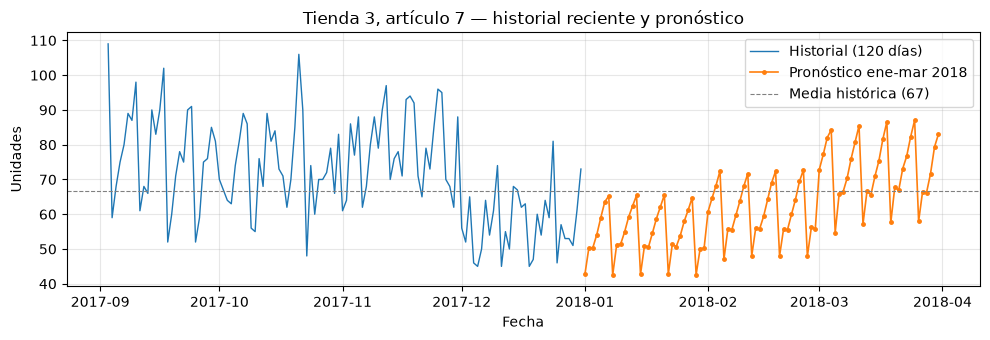

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(gh.tail(120)["date"], gh.tail(120)["sales"], label="Historial (120 días)", lw=1)
ax.plot(gf["date"], gf["sales"], label="Pronóstico ene-mar 2018", marker="o", ms=2.5, lw=1.2)
ax.axhline(h_stats["mean"], color="gray", ls="--", lw=0.8,
           label=f"Media histórica ({h_stats['mean']:.0f})")
ax.set_title(f"Tienda {store}, artículo {item} — historial reciente y pronóstico")
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "insight_serie_ejemplo.png", dpi=150)
plt.show()

## 4. Retrieval de series similares

Con la ficha histórica de la serie objetivo como consulta, el corpus devuelve las
tres series con el perfil más parecido. Esta es la parte de *retrieval* del agente:
entrega evidencia concreta al generador para que el insight no dependa solo de los
números de la serie consultada.

In [6]:
for r in corpus.search(card_3_7["text"], k=3):
    c = next(c for c in cards if c["store"] == r["store"] and c["item"] == r["item"])
    print(f"similitud {r['similarity']:.2f} -> tienda {r['store']}, artículo {r['item']}")
    print("   ", c["text"][:160] + "...")
    print()

similitud 1.00 -> tienda 3, artículo 7
    Tienda 3, artículo 7: media diaria de 66.6 unidades (desvío 18.3, rango 22-123). Tendencia de los últimos 90 días: -18.0% respecto al periodo previo. Mes de may...

similitud 0.72 -> tienda 5, artículo 25
    Tienda 5, artículo 25: media diaria de 61.2 unidades (desvío 17.2, rango 18-123). Tendencia de los últimos 90 días: -22.4% respecto al periodo previo. Mes de ma...

similitud 0.65 -> tienda 9, artículo 14
    Tienda 9, artículo 14: media diaria de 61.5 unidades (desvío 17.1, rango 19-123). Tendencia de los últimos 90 días: -18.3% respecto al periodo previo. Mes de ma...



## 5. Generación de insights

Se instancia el agente con el modelo de Groq. Si `GROQ_API_KEY` está en `.env`,
la generación la hace el LLM; si no, se usa el generador heurístico (reglas sobre
las estadísticas) como baseline. Se analizan tres series con perfiles distintos:
**tienda 3, artículo 7** (demanda media-alta), **tienda 1, artículo 1** (demanda
baja) y **tienda 10, artículo 49** (demanda alta con variabilidad).

In [7]:
api_key = env.get("GROQ_API_KEY", "")
agent = InsightsAgent(model=GROQ_MODEL, api_key=api_key or None)
print("LLM de Groq disponible:", agent.llm_available)
print()

series_objetivo = [(3, 7), (1, 1), (10, 49)]
results = {}
for store, item in series_objetivo:
    r = agent.generate(
        store, item,
        hist[(hist["store"] == store) & (hist["item"] == item)],
        forecast[(forecast["store"] == store) & (forecast["item"] == item)],
        corpus=corpus,
    )
    results[(store, item)] = r
    print(f"--- tienda {store}, artículo {item} ({r['generator']}) ---")
    print(r["response"])
    print()

LLM de Groq disponible: True



--- tienda 3, artículo 7 (llm_groq) ---
En la Tienda 3, artículo 7, se espera una media diaria de 62.6 unidades en ene-mar 2018, un 4.0% menos que el histórico. Esta tendencia a la baja se observa también en series similares, lo que sugiere una posible causa estacional o de mercado. La demanda históricamente más alta en julio y la tendencia decreciente en los últimos 90 días refuerzan esta hipótesis. Se recomienda revisar y ajustar el inventario para evitar sobrestock, considerando promociones o descuentos para impulsar las ventas en enero y febrero, antes del pico esperado en marzo. Esto permitirá a la Tienda 3, artículo 7, mantener un nivel de servicio adecuado y minimizar pérdidas por obsolescencia o sobrestock.



--- tienda 1, artículo 1 (llm_groq) ---
En la Tienda 1, artículo 1, se espera una media diaria de 18.3 unidades en ene-mar 2018, un 8.5% menos que el histórico. Esta tendencia a la baja se observa también en series similares, lo que sugiere una posible causa estacional o de mercado. La demanda históricamente más alta en julio y más baja en enero, junto con el día más fuerte de la semana siendo el domingo, apunta a un patrón de comportamiento de los consumidores. Recomendamos ajustar el inventario y planificar promociones para marzo, cuando se espera un pico en la demanda, para maximizar las ventas y minimizar los costos de sobreinventario en la Tienda 1, artículo 1.



--- tienda 10, artículo 49 (llm_groq) ---
En la Tienda 10, artículo 49, se espera una media diaria de 30.1 unidades en ene-mar 2018, un 3.0% inferior al histórico. Esta tendencia a la baja se observa también en series similares, lo que sugiere una posible causa estacional o de mercado. La tendencia negativa de los últimos 90 días (-22.2%) y la similitud con otras series (Tienda 10, artículo 23; Tienda 3 y 8, artículo 49) refuerzan esta hipótesis. Recomendamos ajustar el inventario y planificar promociones estratégicas para marzo, cuando se espera el pico de demanda, para minimizar el impacto de la tendencia a la baja y maximizar las ventas en la Tienda 10, artículo 49.



## 6. Registro en MLflow

Cada insight se registra como un run del experimento `demand_forecast_insights`
con métricas coherentes del componente genAI: latencia total, latencia del
retrieval y de la generación, tokens usados (si hay LLM) y si el texto menciona
la serie objetivo. Como artefactos se guardan el contexto, las series similares y
el insight.

In [8]:
import mlflow
import os

mlflow.set_tracking_uri(TRACKING_URI)
# El kernel de Jupyter corre con cwd=notebooks/; fijamos el root de artefactos
# para que los runs caigan en mlruns/ de la raíz, no en notebooks/mlruns
os.environ["MLFLOW_DEFAULT_ARTIFACT_ROOT"] = str(ROOT / "mlruns")

for (store, item), res in results.items():
    run_id = log_insight_run(res, INSIGHTS_EXPERIMENT)
    print(f"tienda {store}, artículo {item} -> run {run_id[:8]}")

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tienda 3, artículo 7 -> run ab3d15f0
tienda 1, artículo 1 -> run 5635eb40
tienda 10, artículo 49 -> run f3d37758


In [9]:
exp = mlflow.get_experiment_by_name(INSIGHTS_EXPERIMENT)
df_runs = mlflow.search_runs([exp.experiment_id], order_by=["start_time desc"])
cols = [
    "params.store", "params.item", "params.generator", "params.llm_model",
    "metrics.latency_total_ms", "metrics.total_tokens", "metrics.references_series",
]
df_runs[cols]

,params.store,params.item,params.generator,params.llm_model,metrics.latency_total_ms,metrics.total_tokens,metrics.references_series
0,10,49,llm_groq,llama-3.3-70b-versatile,1051.2968,825.0,1.0
1,1,1,llm_groq,llama-3.3-70b-versatile,1038.3567,813.0,1.0
2,3,7,llm_groq,llama-3.3-70b-versatile,1981.9751,827.0,1.0
3,10,49,heuristica,none,5.0873,0.0,1.0
4,1,1,heuristica,none,5.5914,0.0,1.0
5,3,7,heuristica,none,5.2691,0.0,1.0
6,10,49,heuristica,none,5.2628,0.0,1.0
7,1,1,heuristica,none,4.9545,0.0,1.0
8,3,7,heuristica,none,5.4057,0.0,1.0


## Conclusiones

- El agente combina **contexto + retrieval + generación** (RAG-lite) sobre el
  subconjunto de 150 series: las fichas TF-IDF recuperan series con perfil
  histórico parecido y el LLM (o el heurístico de respaldo) redacta el insight.
- La auto-coincidencia del corpus (la serie se encuentra a sí misma con similitud
  1.0) valida que el índice está bien construido.
- Cada insight queda registrado en MLflow (`demand_forecast_insights`) con métricas
  de latencia, tokens y cobertura de la serie, como evidencia del componente genAI
  del entregable.
- Con `GROQ_API_KEY` en `.env` la generación la hace `llama-3.3-70b-versatile`; sin
  la clave se usa el baseline heurístico para que el flujo no se rompa.